# Volume Slice Viewer
Interactive notebook for browsing all slices using `visualization.py` and the existing config.

In [ ]:
from pipeline_config import load_config
from visualization import main_load_volume, process_volume_base

config = load_config("visualization_config_simulated.cfg")
# config = load_config("visualization_config_raw_data.cfg")

vol_path = config["paths"]["volume_path"]
max_clip = config["processing"]["max_clip"]
align = config["processing"]["align_orientation"]

raw = main_load_volume(vol_path)
vol = process_volume_base(raw, align, max_clip)

print("Volume shape:", vol.shape)

print(config["paths"]["volume_path"])

In [ ]:
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display

# axis_dd = widgets.Dropdown(
#     options=["X","Y","Z"],
#     value="Z",
#     description="Axis"
# )

# slice_slider = widgets.IntSlider(
#     min=0,
#     max=vol.shape[2]-1,
#     step=1,
#     value=vol.shape[2]//2,
#     description="Slice",
#     continuous_update=False
# )

# step_slider = widgets.IntSlider(
#     min=1,
#     max=32,
#     step=1,
#     value=8,
#     description="Every N"
# )

# mode = widgets.ToggleButtons(
#     options=["Single Slice","Grid"],
#     description="Mode"
# )

# def update_slider(*args):
#     if axis_dd.value=="X":
#         slice_slider.max = vol.shape[0]-1
#     elif axis_dd.value=="Y":
#         slice_slider.max = vol.shape[1]-1
#     else:
#         slice_slider.max = vol.shape[2]-1

# axis_dd.observe(update_slider,"value")

# def show(axis,index,every,mode):
#     plt.close("all")

#     cmap = config["slices"].get("cmap", "jet")
    
#     if mode=="Single Slice":
#         if axis=="X":
#             img=vol[index,:,:]
#         elif axis=="Y":
#             img=vol[:,index,:]
#         else:
#             img=vol[:,:,index]

#         plt.figure(figsize=(10, 10))
#         plt.imshow(img,cmap=cmap,vmin=0,vmax=max_clip)
#         plt.title(f"{axis} Slice {index}")
#         plt.axis("off")
#         plt.show()

#     else:
#         if axis=="X":
#             total=vol.shape[0]
#         elif axis=="Y":
#             total=vol.shape[1]
#         else:
#             total=vol.shape[2]

#         ids=list(range(0,total,every))
#         cols=4
#         rows=(len(ids)+cols-1)//cols

#         fig,axs=plt.subplots(rows,cols,figsize=(4*cols,4*rows))
#         axs=axs.ravel()

#         for ax in axs:
#             ax.axis("off")

#         for ax,i in zip(axs,ids):
#             if axis=="X":
#                 img=vol[i,:,:]
#             elif axis=="Y":
#                 img=vol[:,i,:]
#             else:
#                 img=vol[:,:,i]

#             ax.imshow(img,cmap=cmap,vmin=0,vmax=max_clip)
#             ax.set_title(f"{axis}={i}",fontsize=10)
#             ax.axis("off")

#         plt.tight_layout()
#         plt.show()

# widgets.interact(
#     show,
#     axis=axis_dd,
#     index=slice_slider,
#     every=step_slider,
#     mode=mode
# );

In [ ]:
import os
import math
import matplotlib.pyplot as plt
import numpy as np
# ===================== USER SETTINGS =====================

axis = "X"            # "X", "Y", "Z"
nth = 4               # Show every nth slice
cols = 3              # Images per row (ONLY this is fixed)



# figsize = (18, 12)    # Figure size
dpi = 600

# folder = "../May_26th/BS0.09_80RPM/Iso1.0mm_Algo_FDK_CGLS/exp"
# save_path = os.path.join(folder, "8th_slices.png")
# os.makedirs(folder, exist_ok=True)
save_path = 'BS0.09_80RPM_1.6MM_4th_slices_FDK.png'

show_title = True
show_colorbar = False

# =========================================================

cmap = config["slices"].get("cmap", "jet")

# Select slice indices
if axis == "X":
    indices = list(range(0, vol.shape[0], nth))
elif axis == "Y":
    indices = list(range(0, vol.shape[1], nth))
else:
    indices = list(range(0, vol.shape[2], nth))

n_images = len(indices)
rows = math.ceil(n_images / cols)

h, w = vol[10].shape          # height, width of one slice

cell_width = 3          # inches per image
cell_height = cell_width * h / w

figsize = (
    cols * cell_width,
    rows * cell_height,
)

fig, axs = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=dpi
)

# Works for both 1 row and multiple rows
axs = np.array(axs).reshape(-1)

# Hide everything initially
for ax in axs:
    ax.axis("off")

for ax, idx in zip(axs, indices):

    if axis == "X":
        img = vol[idx]
    elif axis == "Y":
        img = vol[:, idx]
    else:
        img = vol[:, :, idx]

    im = ax.imshow(
        img,
        cmap=cmap,
        vmin=0,
        vmax=max_clip,
        interpolation="nearest",
        # aspect="auto",
    )

    if show_title:
        ax.set_title(f"{axis}={idx}", fontsize=9)

    ax.set_xticks([])
    ax.set_yticks([])

    if show_colorbar:
        plt.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.01,
        )

# Remove unused axes
for ax in axs[n_images:]:
    fig.delaxes(ax)

plt.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.98,
    bottom=0.01,
    wspace=0.02,
    hspace=0.06,
)

plt.savefig(
    save_path,
    dpi=dpi,
    bbox_inches="tight",
    pad_inches=0.02,
)

# plt.show()
plt.close(fig)
print(f"Saved {os.path.abspath(save_path)}")




# ------------------------------------------------------------------
# Save each row separately
# ------------------------------------------------------------------

base_name = os.path.splitext(os.path.basename(save_path))[0]
out_dir = base_name
os.makedirs(out_dir, exist_ok=True)

for row in range(rows):

    start = row * cols
    end = min((row + 1) * cols, n_images)

    row_indices = indices[start:end]

    fig, axs = plt.subplots(
        1,
        len(row_indices),
        figsize=(cell_width * len(row_indices), cell_height),
        dpi=dpi,
    )

    # Handle single image case
    if len(row_indices) == 1:
        axs = [axs]

    for ax, idx in zip(axs, row_indices):

        if axis == "X":
            img = vol[idx]
        elif axis == "Y":
            img = vol[:, idx]
        else:
            img = vol[:, :, idx]

        im = ax.imshow(
            img,
            cmap=cmap,
            vmin=0,
            vmax=max_clip,
            interpolation="nearest",
        )

        if show_title:
            ax.set_title(f"{axis}={idx}", fontsize=9)

        ax.set_xticks([])
        ax.set_yticks([])

        if show_colorbar:
            plt.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.01,
            )

    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.95,
        bottom=0.02,
        wspace=0.02,
    )

    row_save_path = os.path.join(
        out_dir,
        f"{base_name}_row_{row+1:02d}.png"
    )

    plt.savefig(
        row_save_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    plt.close(fig)

    print(f"Saved: {row_save_path}")

In [1]:
import numpy as np


np.load("../May_26th/BS0.09_80RPM/Iso1.0mm_Algo_FDK_CGLS/Recon/CGLS.npy").shape#, np.load("../Simulated_Scene/Scene1_converted.npy").shape



(419, 620, 420)

Single from all CGLS folders

CGLS 0: RRMSE = 0.481735
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_0/CGLS_0_X_204.png
CGLS 1: RRMSE = 0.466500
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_1/CGLS_1_X_204.png
CGLS 2: RRMSE = 0.446426
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_2/CGLS_2_X_204.png
CGLS 3: RRMSE = 0.426158
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_3/CGLS_3_X_204.png
CGLS 4: RRMSE = 0.410176
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_4/CGLS_4_X_204.png
CGLS 5: RRMSE = 0.391483
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_5/CGLS_5_X_204.png
CGLS 6: RRMSE = 0.378828
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_6/CGLS_6_X_204.png
CGLS 7: RRMSE = 0.362492
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_7/CGLS_7_X_204.png
CGLS 8: RRMSE = 0.350201
Saved ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_8/CGLS_8_X_204.png
CGLS 9: RRMSE = 0.337738
Saved ../Simulated_Scene_small_Iso1.0mm

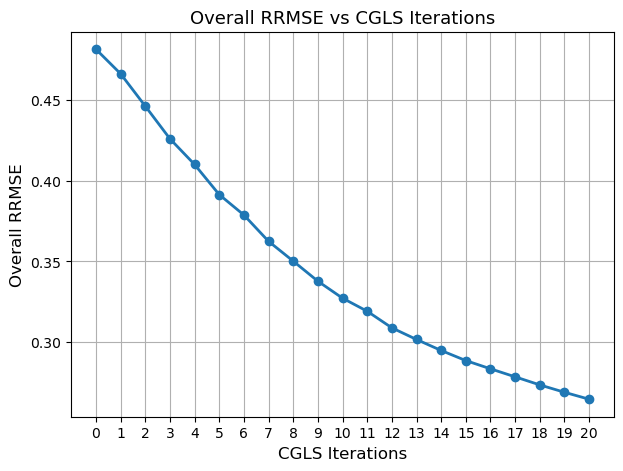

Saved graph to ../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_/CGLS_vs_RRMSE.png


In [14]:
import os
import matplotlib.pyplot as plt

from pipeline_config import load_config
from visualization import main_load_volume, process_volume_base

import numpy as np

def rrmse(reference, test):
    return np.sqrt(np.sum((reference - test) ** 2) /
                   np.sum(reference ** 2))

# ============================================================
# User settings
# ============================================================

# ROOT = "../May_26th_BS0.09_80RPM_Iso1.3mm_Algo_FDK"
ROOT = "../Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_"

SLICE_INDEX = int(204)      # X slice to plot #sim = 204, raw = 264
AXIS = "X"             # X, Y or Z

max_clip = 3.5 # sim == 3; raw == 0.04
DPI = 600
CMAP = "jet"

is_rrmse = True
# cfg = load_config("visualization_config_raw_data.cfg")
cfg = load_config("visualization_config_simulated.cfg")

# max_clip = cfg["processing"]["max_clip"]
align = cfg["processing"]["align_orientation"]

GT_PATH = "../Simulated_Scene/Scene1_small_converted.npy"   # <-- your ground truth
gt = np.load(GT_PATH).astype(np.float32)
gt = process_volume_base(gt, align, max_clip)
# ============================================================


cgls_iters = []
overall_rrmses = []

folders = sorted(
    [
        f for f in os.listdir(ROOT)
        if os.path.isdir(os.path.join(ROOT, f))
        and f.startswith("CGLS_")
        and f.split("_")[-1].isdigit()
    ],
    key=lambda f: int(f.split("_")[-1])
)

for folder in folders:
    try:
        if not folder.startswith("CGLS_"):
            continue

        cgls_iter = int(folder.split('_')[1])
        
        # FDK RAW
        # if cgls_iter == 0:
        #     max_clip = 0.004
        # if cgls_iter == 5:
        #     max_clip = 0.024
        # if cgls_iter in [10,15]:
        #     max_clip = 0.034
        # else:
        #     max_clip = 0.04
        
        # # FDK Sim
        # if cgls_iter == 20:
        #     max_clip = 6.5
        # #     # max_clip = 0.9
        # else:
        #     continue
        # #     max_clip = 3
            
      

        cgls_dir = os.path.join(ROOT, folder)

        # Override volume path
        if cgls_iter == 0:
            cfg["paths"]["volume_path"] = os.path.join(cgls_dir, "Recon", "ChunkFDK.npy")
        else:
            cfg["paths"]["volume_path"] = os.path.join(cgls_dir, "Recon", "CGLS.npy")

        raw = main_load_volume(cfg["paths"]["volume_path"])
        vol = process_volume_base(raw, align, max_clip)
        
        if is_rrmse:
            overall_rrmse = rrmse(gt, vol)
            iteration = int(folder.split("_")[1])
            cgls_iters.append(iteration)
            overall_rrmses.append(overall_rrmse)
            print(f"CGLS {iteration}: RRMSE = {overall_rrmse:.6f}")

        if AXIS == "X":
            gt_slice = gt[SLICE_INDEX]
            recon_slice = vol[SLICE_INDEX]
        elif AXIS == "Y":
            gt_slice = gt[:, SLICE_INDEX]
            recon_slice = vol[:, SLICE_INDEX]
        else:
            gt_slice = gt[:, :, SLICE_INDEX]
            recon_slice = vol[:, :, SLICE_INDEX]
        if is_rrmse:
            slice_rrmse = rrmse(gt_slice, recon_slice)

        plt.figure(figsize=(6, 6))

        rotated_slice = np.rot90(recon_slice, k=1)  
        
        plt.imshow(
            rotated_slice,
            cmap=CMAP,
            vmin=0,
            vmax=max_clip,
            interpolation="nearest",
        )

        plt.title(
            # f"{folder}\n"
            f"CGLS Iter: {folder.split('_')[1]}\n"
            # f"{AXIS}={SLICE_INDEX}"
            # f"| Slice RRMSE={slice_rrmse:.3f}\n"
            # f"Volume RRMSE={overall_rrmse:.4f}"
            ,fontsize=10
        )
        # plt.title(f"CGLS Iter: {folder.split("_")[1]}\n" ,fontsize=10)
        
        plt.xticks([])
        plt.yticks([])

        save_path = os.path.join(
            cgls_dir,
            f"{folder}_{AXIS}_{SLICE_INDEX}.png"
        )

        plt.savefig(
            save_path,
            dpi=DPI,
            bbox_inches="tight",
            pad_inches=0.02,
        )

        plt.close()

        print(f"Saved {save_path}")
        # break
    except Exception as e:
        print("Skipped")
        print(e)
        
if is_rrmse: 
    # ============================================================
    # Plot Overall RRMSE vs CGLS Iterations
    # ============================================================

    plt.figure(figsize=(7, 5))

    plt.plot(
        cgls_iters,
        overall_rrmses,
        marker='o',
        linewidth=2,
    )

    plt.xlabel("CGLS Iterations", fontsize=12)
    plt.ylabel("Overall RRMSE", fontsize=12)
    plt.title("Overall RRMSE vs CGLS Iterations", fontsize=13)

    plt.grid(True)
    plt.xticks(cgls_iters)

    graph_path = os.path.join(ROOT, "CGLS_vs_RRMSE.png")

    plt.savefig(
        graph_path,
        dpi=DPI,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved graph to {graph_path}")

In [ ]:
# Simulated_Scene_small_Iso1.0mm_Algo_FDK_
rrmse__1p0mm = [
    0.982351, 0.862568, 0.795695, 0.733896, 0.682244,
    0.628645, 0.589280, 0.543744, 0.511034, 0.479624,
    0.451742, 0.429443, 0.404371, 0.386988, 0.370105,
    0.357284, 0.343515, 0.332931, 0.321724, 0.312138,
    0.303676
]
# Simulated_Scene_small_Iso1.3mm_Algo_FDK_
rrmse_1p3mm = [
    0.889558, 0.834527, 0.760425, 0.698600, 0.648216,
    0.588676, 0.549882, 0.503639, 0.471674, 0.440885,
    0.413215, 0.391583, 0.368858, 0.352698, 0.336720,
    0.324410, 0.311292, 0.301107, 0.290607, 0.281752,
    0.274495
]

# Simulated_Scene_small_Iso1.0mm_Algo_ChunkFDK_
rrmse_chunkfdk_1p0mm = [
    0.481735, 0.466500, 0.446426, 0.426158, 0.410176,
    0.391483, 0.378828, 0.362492, 0.350201, 0.337738,
    0.327200, 0.319090, 0.308782, 0.301561, 0.294726,
    0.288458, 0.283349, 0.278369, 0.273360, 0.268780,
    0.264470
]
# Simulated_Scene_small_Iso1.3mm_Algo_ChunkFDK_
rrmse_chunkfdk_1p3mm = [
    0.494928, 0.478173, 0.451808, 0.427670, 0.409740,
    0.385851, 0.371296, 0.351719, 0.338043, 0.325590,
    0.313216, 0.303705, 0.293201, 0.285604, 0.277927,
    0.272046, 0.265737, 0.260603, 0.255170, 0.250576,
    0.246806
]

Plot T vs I graph

In [ ]:
import matplotlib.pyplot as plt

# Hardcoded data extracted from the table
# BS0.09_80RPM
time = [
    39, 62, 85, 108, 131, 154, 177, 200, 223, 245,
    269, 292, 316, 339, 361, 384, 407, 429, 453, 475
]



iterations = list(range(1, 21))
min_time = min(time)
max_time = max(time)

# Figure Setup
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Modern Line Plot: Indigo color, subtle hollow markers, smooth line width
ax.plot(
    iterations, time,
    color='#4F46E5',          # Modern Indigo Hex
    linestyle='-',            # Clean solid line
    linewidth=2.5,            # Slightly thicker line
    marker='o',               # Circular marker
    markersize=6,             # Subtle size
    markerfacecolor='white',  # Hollow center
    markeredgecolor='#4F46E5',# Matching border color
    markeredgewidth=2,
    label='CGLS Time'
)

# Y-Axis Formatting
ax.set_yticks([min_time, 100, 200, 300, 400, max_time])
ax.set_ylim(0, 500)

# Minimalist Spines (Remove top and right borders)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#94A3B8')
# ax.spines['bottom'].set_color('#94A3B8')

# Soft, Modern Gridlines
ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')

# Typography & Labels
ax.set_title('CGLS Performance: Iteration vs Time', fontsize=13, fontweight='bold', pad=15, color='#0F172A')
ax.set_xlabel('Iteration', fontsize=13, fontweight='medium')#, color='#334155')
ax.set_ylabel('Time (sec)', fontsize=13, fontweight='medium')#, color='#334155')
ax.set_xticks(iterations)
# ax.tick_params(colors='#475569')

# Annotations (Min/Max)
# ax.annotate(f'Min: {min_time}', (1, min_time), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#4F46E5')
# ax.annotate(f'Max: {max_time}', (20, max_time), textcoords="offset points", xytext=(0, -18), ha='center', fontweight='bold', color='#4F46E5')

plt.tight_layout()
plt.savefig('cgls_modern_plot.png', dpi=300, bbox_inches='tight')
plt.show()

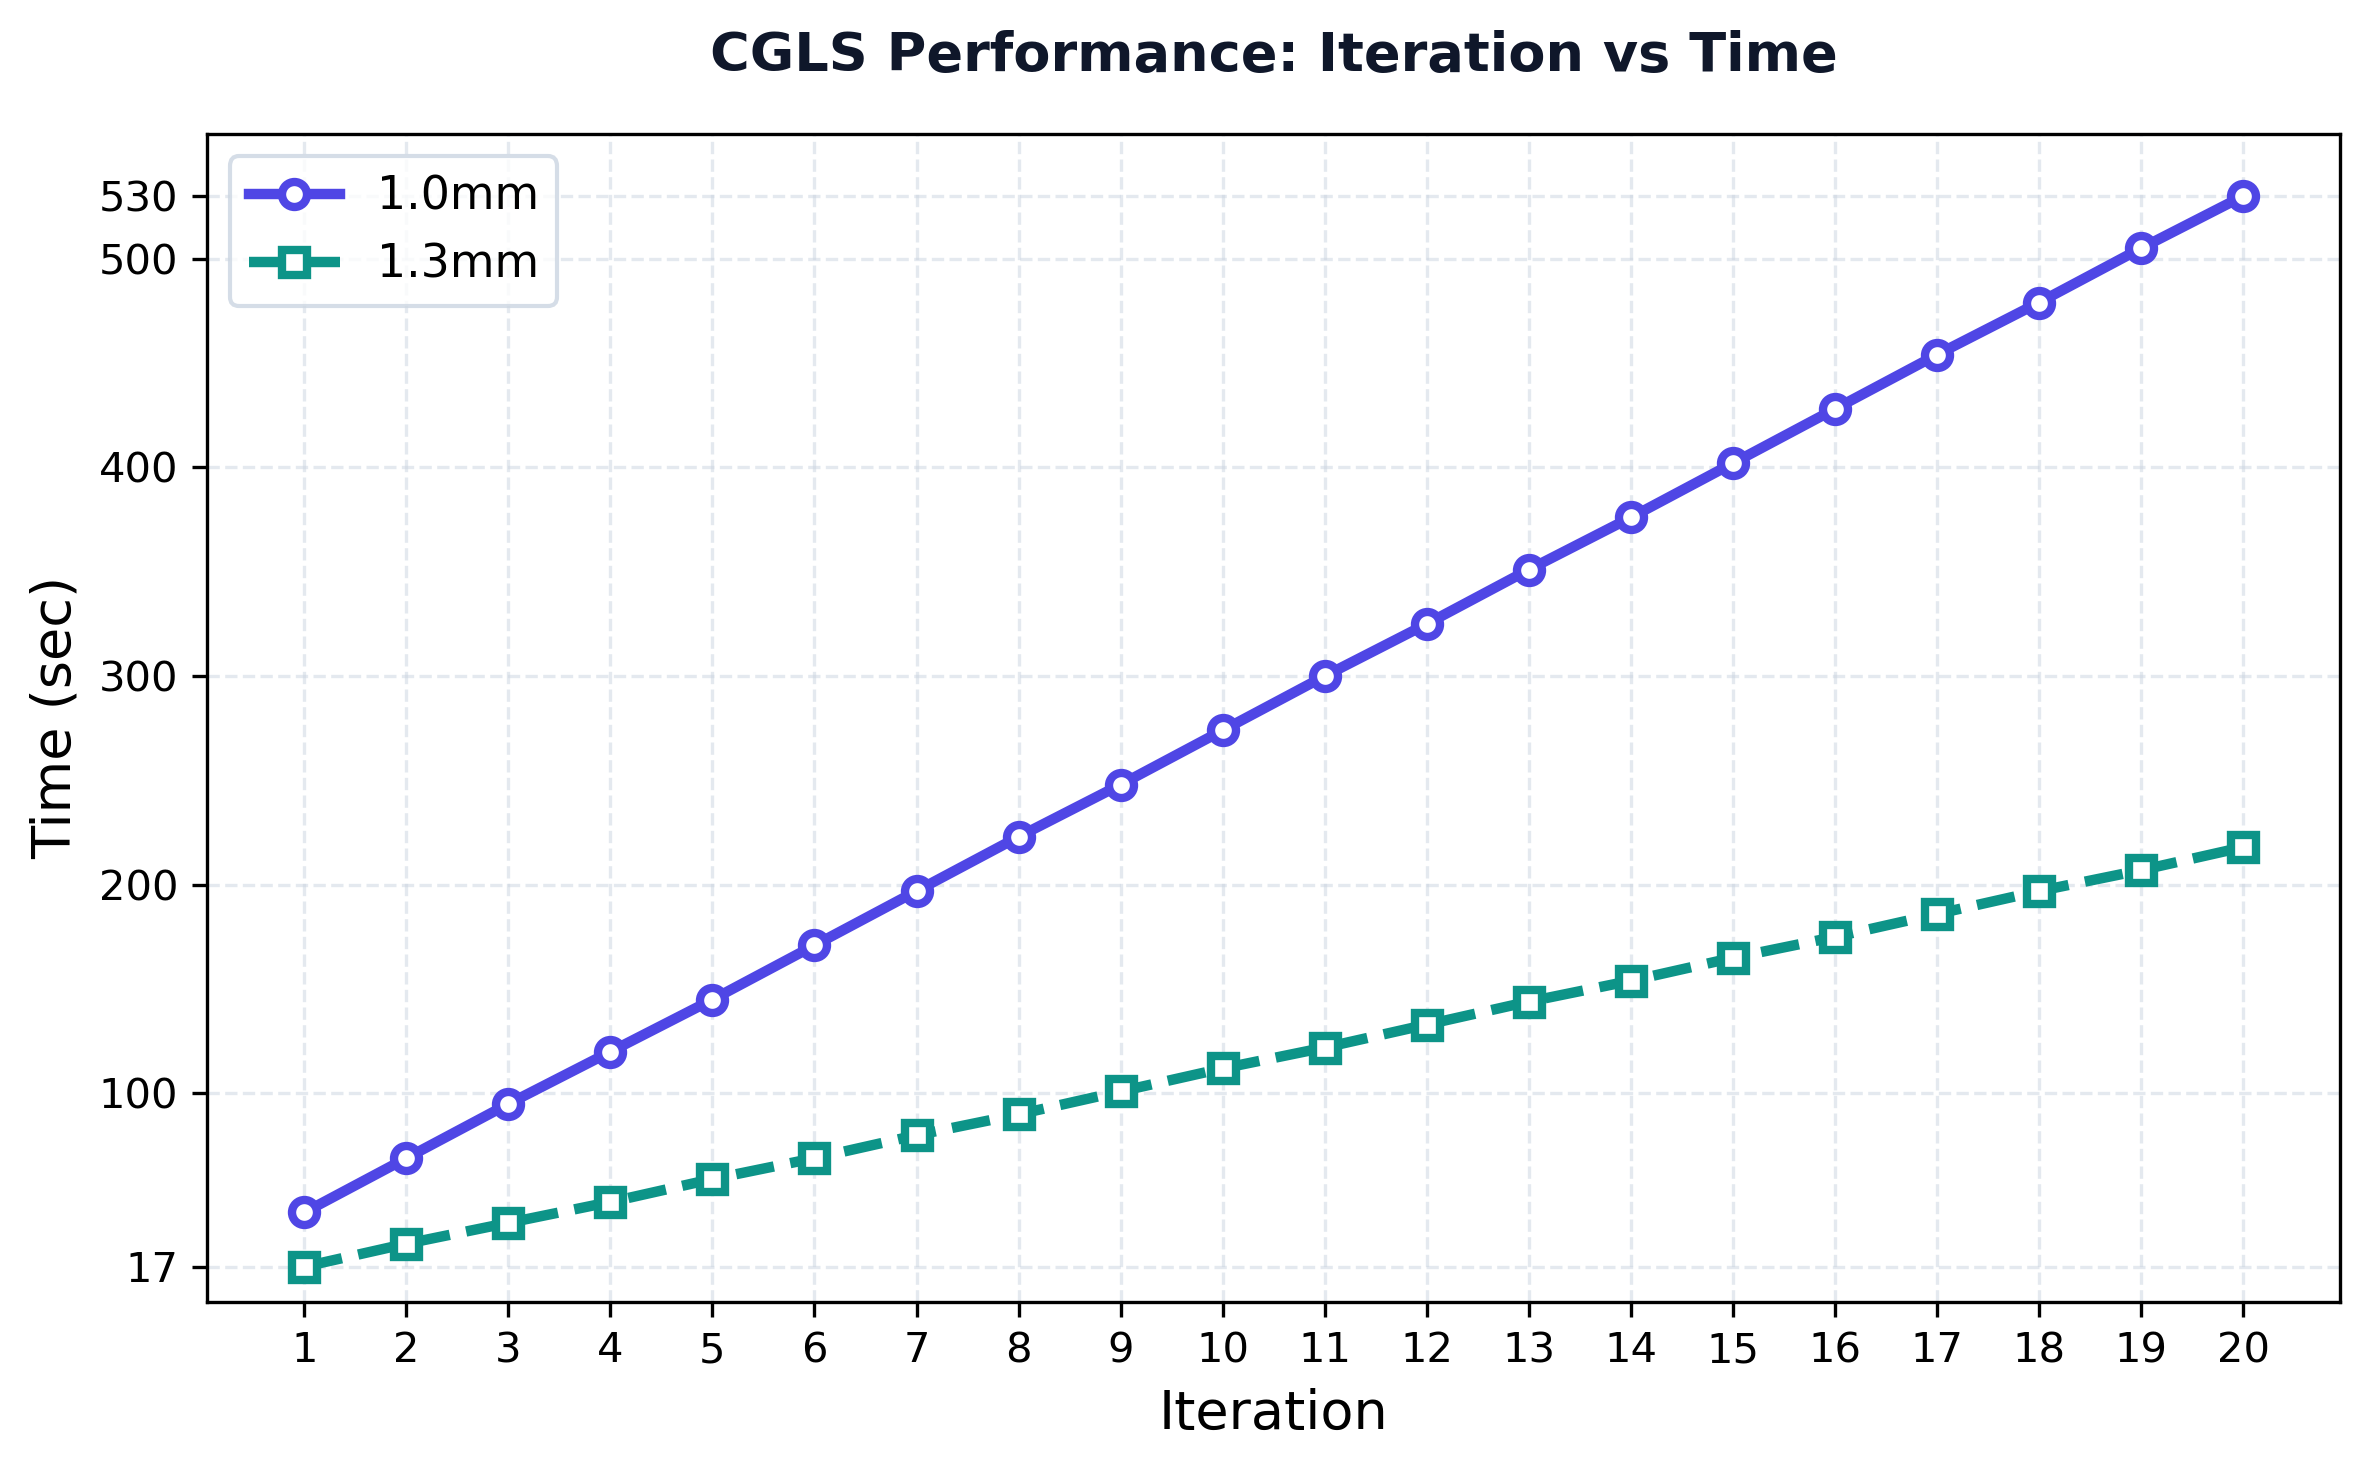

In [ ]:
import matplotlib.pyplot as plt

# Dataset 1: 1.0mm (Original Data) 20 chunks || (429, 620, 420)
iterations = list(range(1, 21))
time_1_0mm = [43, 69, 95, 120, 145, 171, 197, 223, 248, 274, 300, 325, 351, 376, 402, 428, 454, 479, 505, 530]

# Dataset 2: 1.3mm (Example / Place-holder values - update these with your real data) 15 chunks || (330, 477, 323)
time_1_3mm = [17, 28, 38, 48, 59, 69, 80, 90, 101, 112, 122, 133, 144, 154, 165, 175, 186, 197, 207, 218]

# Calculate combined Min and Max for y-axis ticks
all_times = time_1_0mm + time_1_3mm
min_time = min(all_times)
max_time = max(all_times)

# Figure Setup
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Curve 1: 1.0mm (Modern Indigo)
ax.plot(
    iterations, time_1_0mm,
    color='#4F46E5',          # Indigo
    linestyle='-',            # Solid line
    linewidth=2.5,
    marker='o',               # Circle marker
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#4F46E5',
    markeredgewidth=2,
    label='1.0mm'
)

# Curve 2: 1.3mm (Modern Teal)
ax.plot(
    iterations, time_1_3mm,
    color='#0D9488',          # Teal
    linestyle='--',           # Dashed line (helps differentiate visually)
    linewidth=2.5,
    marker='s',               # Square marker
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#0D9488',
    markeredgewidth=2,
    label='1.3mm'
)

# Y-Axis Formatting (Dynamic range from global min to global max)
ax.set_yticks([min_time, 100, 200, 300, 400, 500, max_time])
ax.set_ylim(0, max_time + 30)

# Soft Gridlines
ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')

# Typography & Labels
ax.set_title('CGLS Performance: Iteration vs Time', fontsize=13, fontweight='bold', pad=15, color='#0F172A')
ax.set_xlabel('Iteration', fontsize=13, fontweight='medium')
ax.set_ylabel('Time (sec)', fontsize=13, fontweight='medium')
ax.set_xticks(iterations)

# Legend Configuration
ax.legend(frameon=True, facecolor='white', edgecolor='#CBD5E1', fontsize=11)

plt.tight_layout()
plt.savefig('cgls_multi_curve_plot.png', dpi=300, bbox_inches='tight')
plt.show()

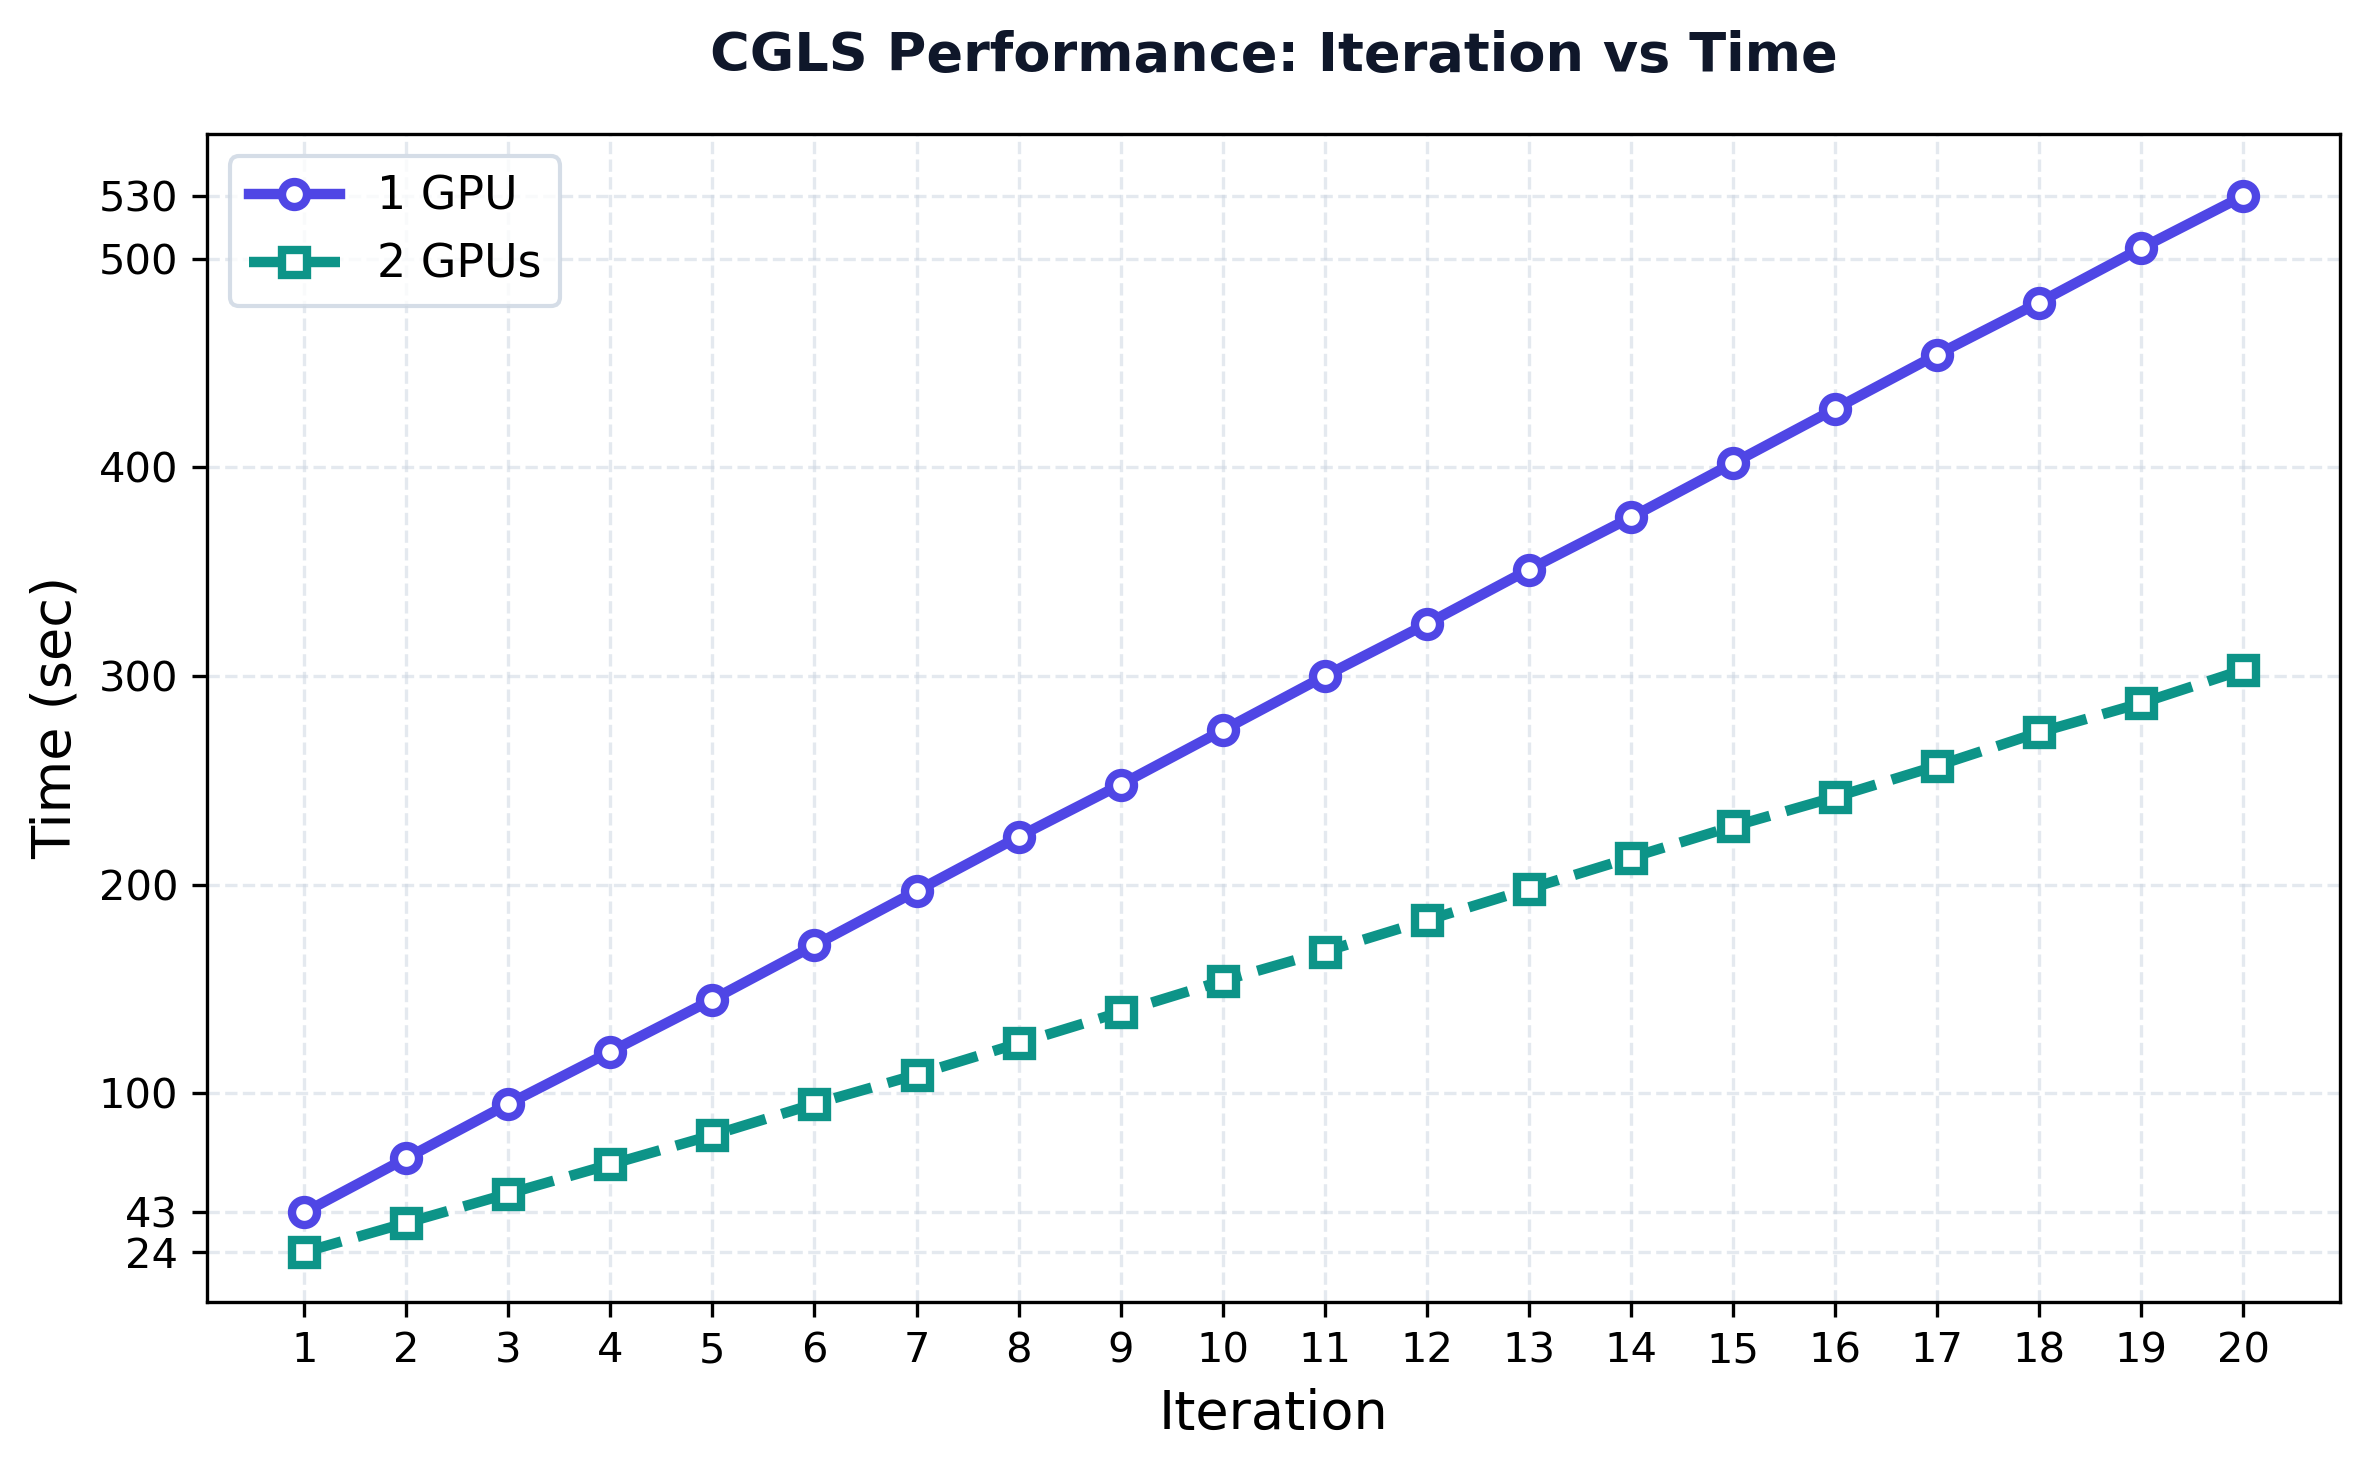

In [2]:
import matplotlib.pyplot as plt

# Dataset 1: 1.0mm (Original Data) 20 chunks || (429, 620, 420)
iterations = list(range(1, 21))
time_1_0mm = [43, 69, 95, 120, 145, 171, 197, 223, 248, 274, 300, 325, 351, 376, 402, 428, 454, 479, 505, 530]

# Dataset 2: 1.0 with 2 GPU 
time_1_0mmmg = [24, 38, 52, 66, 80, 95, 109, 124, 139, 154, 168, 183, 198, 213, 228, 242, 257, 273, 287, 303]

# Calculate combined Min and Max for y-axis ticks
all_times = time_1_0mm + time_1_0mmmg
min_time = min(all_times)
max_time = max(all_times)

# Figure Setup
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Curve 1: 1.0mm (Modern Indigo)
ax.plot(
    iterations, time_1_0mm,
    color='#4F46E5',          # Indigo
    linestyle='-',            # Solid line
    linewidth=2.5,
    marker='o',               # Circle marker
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#4F46E5',
    markeredgewidth=2,
    label='1 GPU'
)

# Curve 2: 1.3mm (Modern Teal)
ax.plot(
    iterations, time_1_0mmmg,
    color='#0D9488',          # Teal
    linestyle='--',           # Dashed line (helps differentiate visually)
    linewidth=2.5,
    marker='s',               # Square marker
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#0D9488',
    markeredgewidth=2,
    label='2 GPUs'
)

# Y-Axis Formatting (Dynamic range from global min to global max)
ax.set_yticks([24, 43, 100, 200, 300, 400, 500, max_time])
ax.set_ylim(0, max_time + 30)

# Soft Gridlines
ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')

# Typography & Labels
ax.set_title('CGLS Performance: Iteration vs Time', fontsize=13, fontweight='bold', pad=15, color='#0F172A')
ax.set_xlabel('Iteration', fontsize=13, fontweight='medium')
ax.set_ylabel('Time (sec)', fontsize=13, fontweight='medium')
ax.set_xticks(iterations)

# Legend Configuration
ax.legend(frameon=True, facecolor='white', edgecolor='#CBD5E1', fontsize=11)

plt.tight_layout()
plt.savefig('cgls_multi_curve_plot.png', dpi=300, bbox_inches='tight')
plt.show()

RRMSE

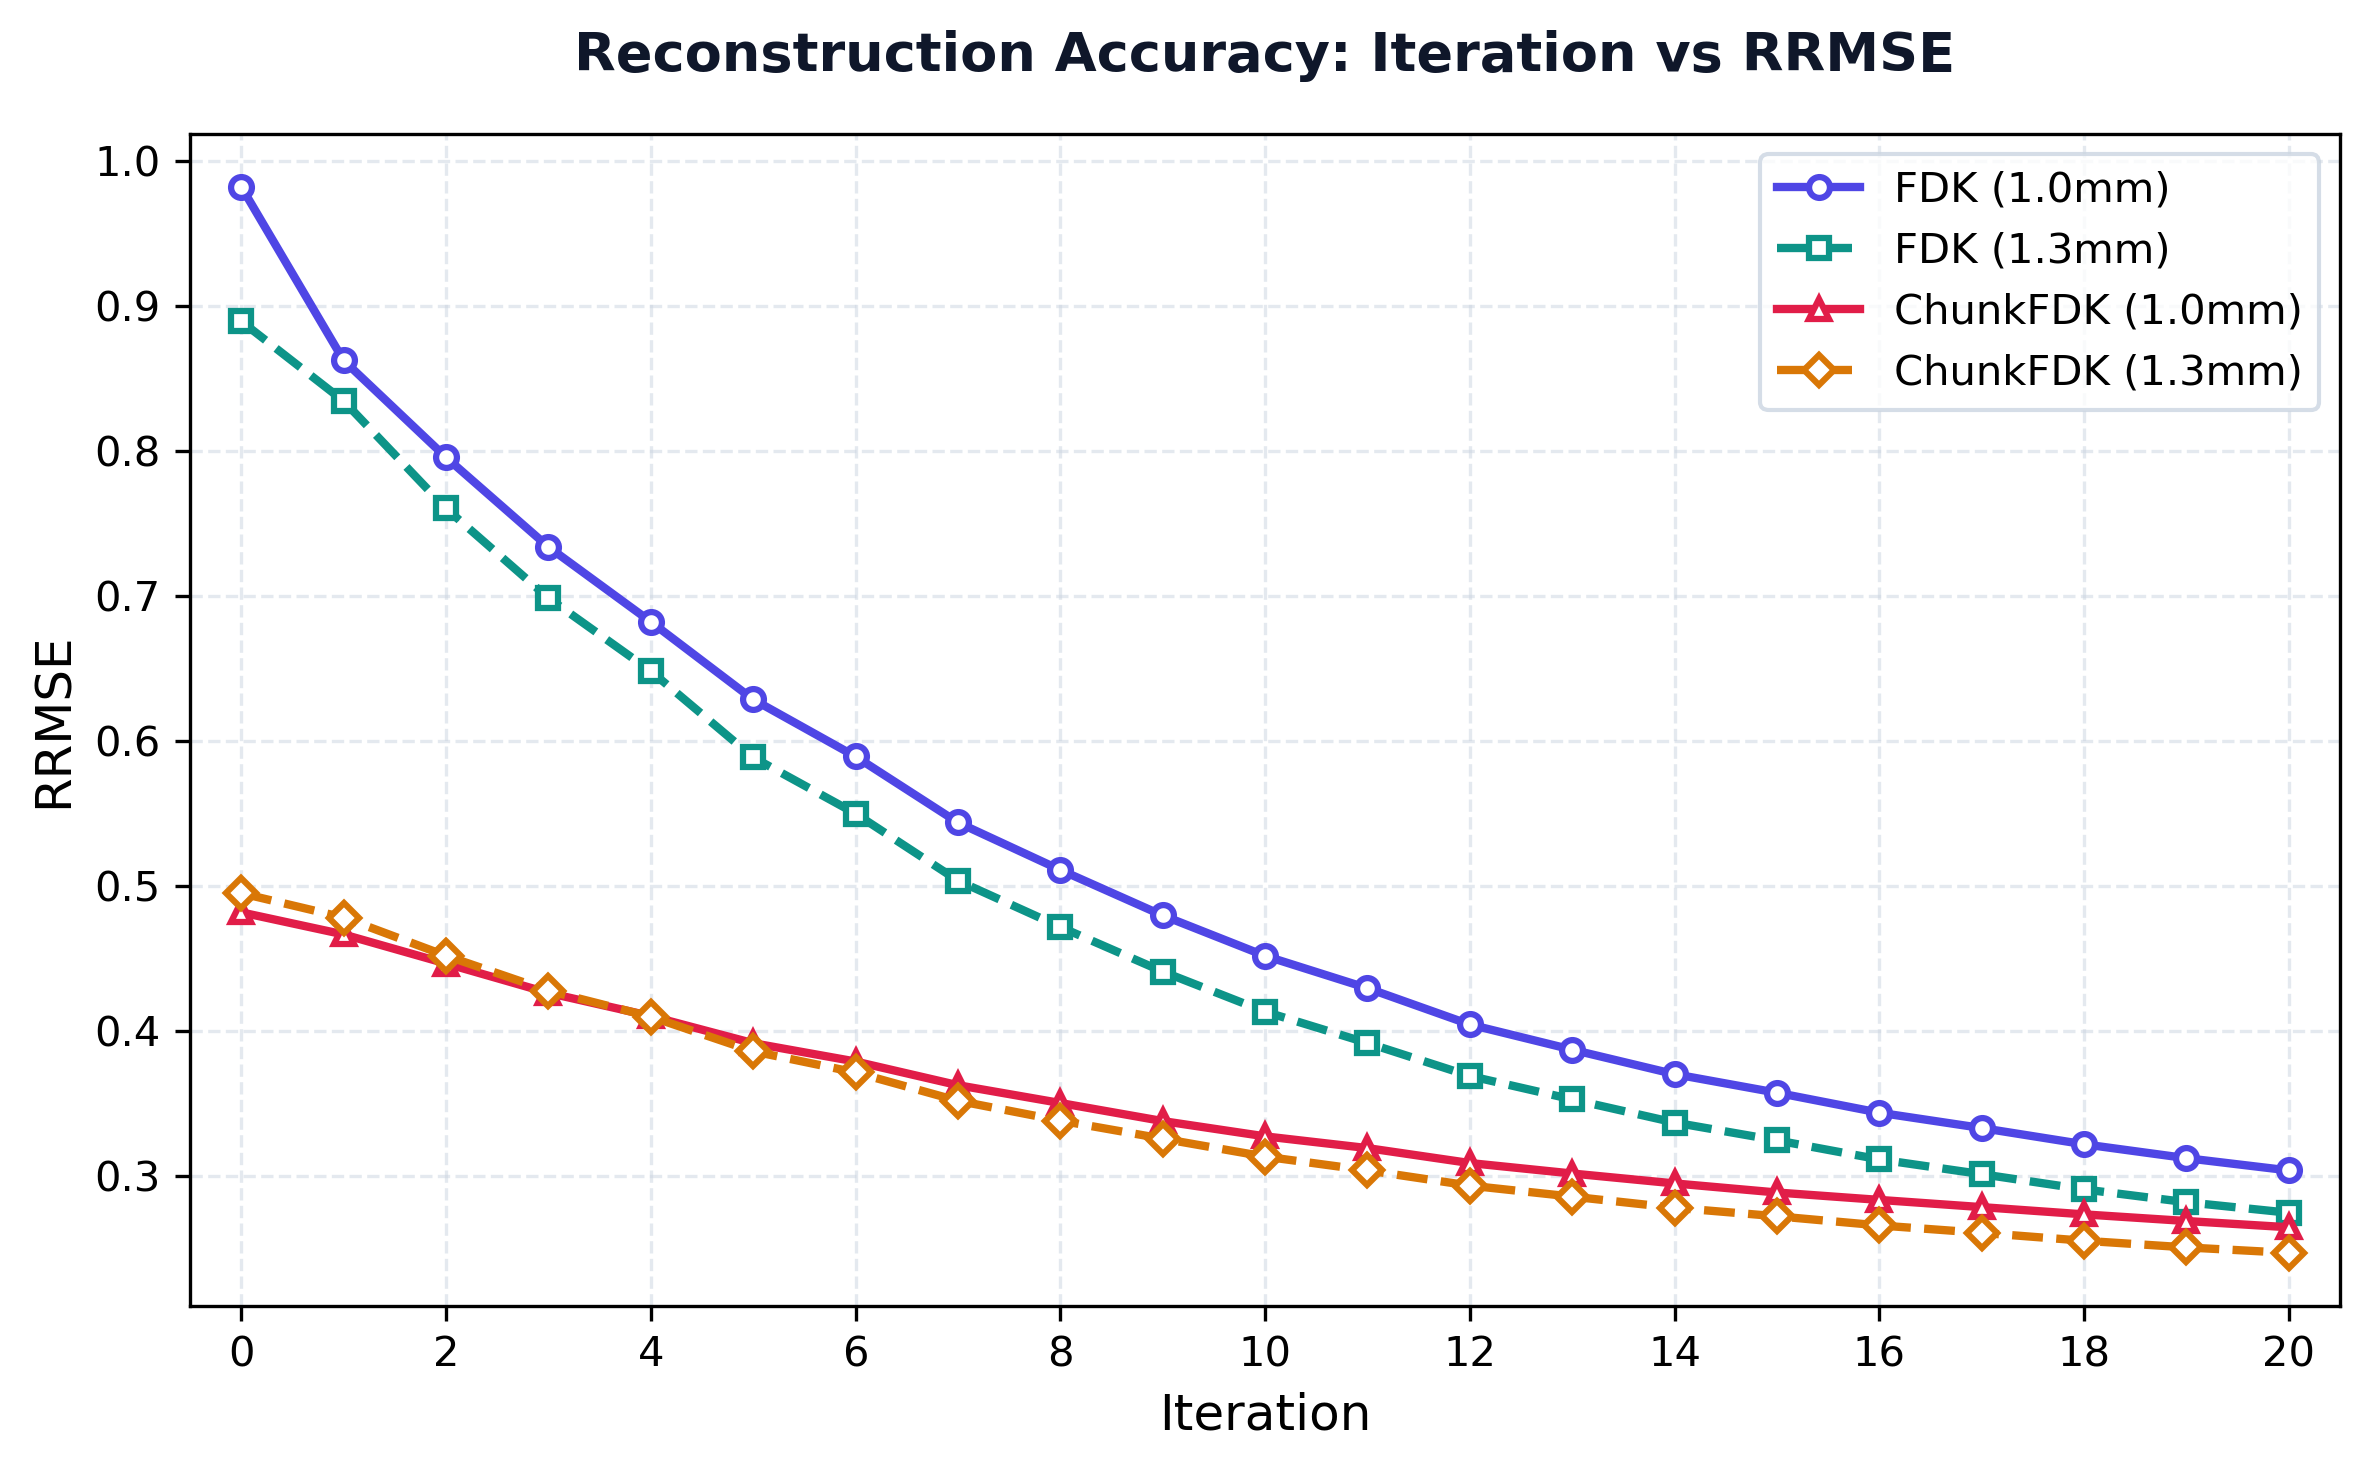

In [4]:
import matplotlib.pyplot as plt

# Iterations starting from 0 to 20
iterations = list(range(0, 21))

# --- RRMSE Datasets ---
# Added initial value at index 0 (e.g., 1.0) for iteration 0
rrmse_1p0mm = [
    0.982351, 0.862568, 0.795695, 0.733896, 0.682244,
    0.628645, 0.589280, 0.543744, 0.511034, 0.479624,
    0.451742, 0.429443, 0.404371, 0.386988, 0.370105,
    0.357284, 0.343515, 0.332931, 0.321724, 0.312138,
    0.303676
]

rrmse_1p3mm = [
    0.889558, 0.834527, 0.760425, 0.698600, 0.648216,
    0.588676, 0.549882, 0.503639, 0.471674, 0.440885,
    0.413215, 0.391583, 0.368858, 0.352698, 0.336720,
    0.324410, 0.311292, 0.301107, 0.290607, 0.281752,
    0.274495
]

rrmse_chunkfdk_1p0mm = [
    0.481735, 0.466500, 0.446426, 0.426158, 0.410176,
    0.391483, 0.378828, 0.362492, 0.350201, 0.337738,
    0.327200, 0.319090, 0.308782, 0.301561, 0.294726,
    0.288458, 0.283349, 0.278369, 0.273360, 0.268780,
    0.264470
]

rrmse_chunkfdk_1p3mm = [
    0.494928, 0.478173, 0.451808, 0.427670, 0.409740,
    0.385851, 0.371296, 0.351719, 0.338043, 0.325590,
    0.313216, 0.303705, 0.293201, 0.285604, 0.277927,
    0.272046, 0.265737, 0.260603, 0.255170, 0.250576,
    0.246806
]

# Figure Setup
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Curve 1: FDK 1.0mm
ax.plot(
    iterations, rrmse_1p0mm,
    color='#4F46E5',           # Indigo
    linestyle='-',
    linewidth=2,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#4F46E5',
    markeredgewidth=1.5,
    label='FDK (1.0mm)'
)

# Curve 2: FDK 1.3mm
ax.plot(
    iterations, rrmse_1p3mm,
    color='#0D9488',           # Teal
    linestyle='--',
    linewidth=2,
    marker='s',
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#0D9488',
    markeredgewidth=1.5,
    label='FDK (1.3mm)'
)

# Curve 3: ChunkFDK 1.0mm
ax.plot(
    iterations, rrmse_chunkfdk_1p0mm,
    color='#E11D48',           # Crimson/Rose
    linestyle='-',
    linewidth=2,
    marker='^',
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#E11D48',
    markeredgewidth=1.5,
    label='ChunkFDK (1.0mm)'
)

# Curve 4: ChunkFDK 1.3mm
ax.plot(
    iterations, rrmse_chunkfdk_1p3mm,
    color='#D97706',           # Amber
    linestyle='--',
    linewidth=2,
    marker='D',
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#D97706',
    markeredgewidth=1.5,
    label='ChunkFDK (1.3mm)'
)

# Formatting
ax.set_title('Reconstruction Accuracy: Iteration vs RRMSE', fontsize=13, fontweight='bold', pad=15, color='#0F172A')
ax.set_xlabel('Iteration', fontsize=12, fontweight='medium')
ax.set_ylabel('RRMSE', fontsize=12, fontweight='medium')

# X Axis settings starting explicitly at 0
ax.set_xticks(range(0, 21, 2))
ax.set_xlim(-0.5, 20.5)

# Soft Gridlines
ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')

# Legend Configuration
ax.legend(frameon=True, facecolor='white', edgecolor='#CBD5E1', fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('rrmse_vs_iterations.png', dpi=300, bbox_inches='tight')
plt.show()